# Lab 3 - Data Cleaning with Pandas

## Objective

Transform messy data into a clean and reliable dataset by:
- Profiling missing values
- Fixing incorrect data types
- Handling duplicates
- Detecting outliers using IQR
- Validating the cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/employee_data.csv")
df

,Name,Age,Department,Salary,JoinDate
0,Rahul,23,IT,40000.0,2024-01-10
1,Priya,NaN,HR,45000.0,2024-02-15
2,Aman,twenty,IT,50000.0,2024-03-01
3,Simran,25,Sales,9999999.0,invalid
4,Rahul,23,IT,40000.0,2024-01-10
5,Karan,29,NaN,55000.0,2024-04-20
6,Neha,27,HR,NaN,2024-05-11


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(pd.__version__)

3.0.5


In [4]:
import os
print(os.getcwd())

/mnt/c/Users/gursi/OneDrive/Desktop/vcreatek-training/week2/data-cleaning/notebooks


In [5]:
df.shape


(7, 5)

In [6]:
df.columns


Index(['Name', 'Age', 'Department', 'Salary', 'JoinDate'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        7 non-null      str    
 1   Age         6 non-null      str    
 2   Department  6 non-null      str    
 3   Salary      6 non-null      float64
 4   JoinDate    7 non-null      str    
dtypes: float64(1), str(4)
memory usage: 412.0 bytes


In [8]:
df.describe(include="all")

,Name,Age,Department,Salary,JoinDate
count,7,6,6,6.000000e+00,7
unique,6,5,3,NaN,6
top,Rahul,23,IT,NaN,2024-01-10
freq,2,2,3,NaN,2
mean,NaN,NaN,NaN,1.705000e+06,NaN
std,NaN,NaN,NaN,4.063707e+06,NaN
min,NaN,NaN,NaN,4.000000e+04,NaN
25%,NaN,NaN,NaN,4.125000e+04,NaN
50%,NaN,NaN,NaN,4.750000e+04,NaN
75%,NaN,NaN,NaN,5.375000e+04,NaN


In [9]:
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

missing_report

,Missing Count,Missing Percentage
Name,0,0.000000
Age,1,14.285714
Department,1,14.285714
Salary,1,14.285714
JoinDate,0,0.000000


In [10]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df

,Name,Age,Department,Salary,JoinDate
0,Rahul,23.0,IT,40000.0,2024-01-10
1,Priya,NaN,HR,45000.0,2024-02-15
2,Aman,NaN,IT,50000.0,2024-03-01
3,Simran,25.0,Sales,9999999.0,invalid
4,Rahul,23.0,IT,40000.0,2024-01-10
5,Karan,29.0,NaN,55000.0,2024-04-20
6,Neha,27.0,HR,NaN,2024-05-11


In [11]:
df["Age"]

0    23.0
1     NaN
2     NaN
3    25.0
4    23.0
5    29.0
6    27.0
Name: Age, dtype: float64

In [12]:
df["JoinDate"] = pd.to_datetime(df["JoinDate"], errors="coerce")
df

,Name,Age,Department,Salary,JoinDate
0,Rahul,23.0,IT,40000.0,2024-01-10
1,Priya,NaN,HR,45000.0,2024-02-15
2,Aman,NaN,IT,50000.0,2024-03-01
3,Simran,25.0,Sales,9999999.0,NaT
4,Rahul,23.0,IT,40000.0,2024-01-10
5,Karan,29.0,NaN,55000.0,2024-04-20
6,Neha,27.0,HR,NaN,2024-05-11


In [13]:
df.dtypes

Name                     str
Age                  float64
Department               str
Salary               float64
JoinDate      datetime64[us]
dtype: object

In [14]:
df["Age"].median()

np.float64(25.0)

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [16]:
df["Department"].mode()

0    IT
Name: Department, dtype: str

In [17]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

In [18]:
df["Salary"].median()

np.float64(47500.0)

In [19]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [20]:
df.isnull().sum()

Name          0
Age           0
Department    0
Salary        0
JoinDate      1
dtype: int64

In [21]:
df.duplicated()

0    False
1    False
2    False
3    False
4     True
5    False
6    False
dtype: bool

In [22]:
df[df.duplicated()]

,Name,Age,Department,Salary,JoinDate
4,Rahul,23.0,IT,40000.0,2024-01-10


In [23]:
df = df.drop_duplicates()

In [24]:
df.shape

(6, 5)

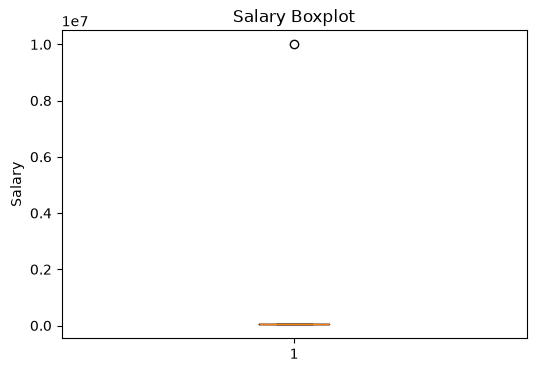

In [25]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Salary"])

plt.title("Salary Boxplot")
plt.ylabel("Salary")

plt.show()

In [26]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 45625.0
Q3: 53750.0


In [27]:
IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 8125.0


In [28]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

Lower: 33437.5
Upper: 65937.5


In [29]:
outliers = df[(df["Salary"] < lower) | (df["Salary"] > upper)]

outliers

,Name,Age,Department,Salary,JoinDate
3,Simran,25.0,Sales,9999999.0,NaT


In [30]:
df = df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]

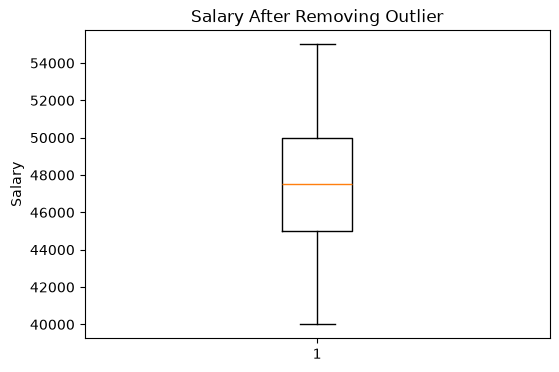

In [31]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Salary"])

plt.title("Salary After Removing Outlier")
plt.ylabel("Salary")

plt.show()

In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 5 entries, 0 to 6
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Name        5 non-null      str           
 1   Age         5 non-null      float64       
 2   Department  5 non-null      str           
 3   Salary      5 non-null      float64       
 4   JoinDate    5 non-null      datetime64[us]
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 240.0 bytes


In [33]:
df.isnull().sum()
df.describe()

,Age,Salary,JoinDate
count,5.000000,5.000000,5
mean,25.800000,47500.000000,2024-03-12 00:00:00
min,23.000000,40000.000000,2024-01-10 00:00:00
25%,25.000000,45000.000000,2024-02-15 00:00:00
50%,25.000000,47500.000000,2024-03-01 00:00:00
75%,27.000000,50000.000000,2024-04-20 00:00:00
max,29.000000,55000.000000,2024-05-11 00:00:00
std,2.280351,5590.169944,NaN
